In [1]:
!pip install -q -U transformers accelerate bitsandbytes datasets sentencepiece pandas textstat rouge-score bert-score sacrebleu matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 100.6 MB/s eta 0:00:00
ERRO

In [2]:
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt

from textstat import flesch_kincaid_grade, automated_readability_index
from rouge_score import rouge_scorer
from bert_score import score as bertscore_score

from transformers import AutoTokenizer, AutoModelForCausalLM

In [3]:
# Hugging Face login.
# Some models require accepting the model license on Hugging Face first.
# In Colab: left sidebar → Secrets → add HF_TOKEN with your Hugging Face READ token.

from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Logged in to Hugging Face.")
else:
    print("No HF_TOKEN found. If this model is gated, loading will fail until you add HF_TOKEN.")


Logged in to Hugging Face.


In [4]:
# Change this if your file name is different
DATA_PATH = "/content/pilot_20_baseline_eval.csv"

df = pd.read_csv(DATA_PATH)

print("Columns found:")
print(df.columns.tolist())
print("\nNumber of rows:", len(df))

df.head()

Columns found:
['example_id', 'act_name', 'section_id', 'unit_label', 'unit_type', 'page_start', 'source_text', 'has_modal', 'has_exception', 'has_numbers', 'has_roles', 'needs_context', 'bad_fragment', 'simple_text', 'split', 'notes', 'pilot_category', 'llama3.2_output', 'qwen3_output', 'mistral_output', 'gemma_output', 'flan_t5_output', 'bart_output']

Number of rows: 20


,example_id,act_name,section_id,unit_label,unit_type,page_start,source_text,has_modal,has_exception,has_numbers,...,simple_text,split,notes,pilot_category,llama3.2_output,qwen3_output,mistral_output,gemma_output,flan_t5_output,bart_output
0,SL00023,Penal Code,Section 22,NaN,section_body,NaN,Whoever does anything with the intention of ca...,0,0,1,...,A person acts dishonestly if they intend to ca...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
1,SL00135,Penal Code,Section 100,explanation,explanation,30.0,A person who. by willful misrepresentation or ...,0,0,1,...,A person instigates an act if they deliberatel...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
2,SL00022,Penal Code,Section 20,4,subsection,8.0,A person is said to lose wrongfully when such...,0,0,1,...,A person does not only lose property wrongfull...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
3,SL00045,Penal Code,Section 35,NaN,section_body,11.0,When an offence is committed by means of sever...,0,0,1,...,f a crime is carried out through a series of s...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN
4,SL00049,Penal Code,Section 37,NaN,section_body,NaN,A person is said to cause an effect 'voluntari...,0,0,1,...,A person acts voluntarily if they meant to bri...,train,NaN,definition,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Required input columns
required_columns = ["source_text", "simple_text"]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Input CSV is valid.")

Input CSV is valid.


In [6]:
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
MODEL_LABEL = "Llama 3.2 3B Instruct"

OUTPUT_COLUMN = "llama32_output"
FKGL_COLUMN = "llama32_fkgl"
ARI_COLUMN = "llama32_ari"
ROUGE_COLUMN = "llama32_rougeL"
BERTSCORE_COLUMN = "llama32_bertscore_f1"

In [7]:
# Create model-specific output columns if they don't already exist
columns_to_create = [
    OUTPUT_COLUMN,
    FKGL_COLUMN,
    ARI_COLUMN,
    ROUGE_COLUMN,
    BERTSCORE_COLUMN
]

for col in columns_to_create:
    if col not in df.columns:
        df[col] = None

print("Model-specific columns are ready.")

Model-specific columns are ready.


In [8]:
from transformers import BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Llama tokenizer has no pad token by default; set it to eos_token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
).eval()

print("Model loaded in 4-bit.")
print("CUDA available:", torch.cuda.is_available())


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded in 4-bit.
CUDA available: True


In [9]:
def build_messages(source_text: str):
    return [
        {"role": "system", "content": "You are a careful legal simplification assistant."},
        {"role": "user", "content": f"""Simplify the Sri Lankan legal provision below into plain English.

Rules:
- Preserve the legal meaning as closely as possible.
- Keep SHALL, MAY, SHALL NOT.
- Keep numbers, dates, fines, punishments, conditions, exceptions, and legal roles.
- Do not add examples, commentary, or legal advice.

Provision:
{source_text}

Plain English:"""}
    ]


In [10]:
MAX_INPUT_TOKENS = 1024
MAX_NEW_TOKENS = 192

def generate_output(source_text: str) -> str:
    messages = build_messages(source_text)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_ids = outputs[0][input_len:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    del inputs, outputs, generated_ids
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return text


In [11]:
# Optional quick test.
# Keep this False when using Colab Free, because testing first generates extra outputs and wastes RAM/time.
RUN_QUICK_TEST = False

if RUN_QUICK_TEST:
    for i in range(min(1, len(df))):
        source = str(df.loc[i, "source_text"])
        gold = str(df.loc[i, "simple_text"]) if pd.notna(df.loc[i, "simple_text"]) else ""

        pred = generate_output(source)

        print("ROW:", i)
        print("\nSOURCE:\n", source)
        print("\nGOLD SIMPLE TEXT:\n", gold)
        print("\nMODEL OUTPUT:\n", pred)
        print("\n" + "=" * 100 + "\n")
else:
    print("Quick test skipped. Set RUN_QUICK_TEST=True if you want to test one row first.")


Quick test skipped. Set RUN_QUICK_TEST=True if you want to test one row first.


In [12]:
# RAM-safe generation loop with checkpoint saving.
# This saves after every row, so if Colab crashes you can rerun and continue.
import os

CHECKPOINT_PATH = "/content/llama32_generation_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    if OUTPUT_COLUMN in checkpoint_df.columns and len(checkpoint_df) == len(df):
        df[OUTPUT_COLUMN] = checkpoint_df[OUTPUT_COLUMN]
        print(f"Loaded existing checkpoint: {CHECKPOINT_PATH}")
    else:
        print("Checkpoint found but does not match this dataset. Starting fresh.")
else:
    print("No checkpoint found. Starting fresh.")

for idx, text in df["source_text"].fillna("").astype(str).items():
    existing = df.loc[idx, OUTPUT_COLUMN] if OUTPUT_COLUMN in df.columns else None

    if isinstance(existing, str) and existing.strip():
        print(f"Skipping row {idx + 1}/{len(df)} - already generated")
        continue

    pred = generate_output(text)
    df.loc[idx, OUTPUT_COLUMN] = pred

    # Save after every row
    df.to_csv(CHECKPOINT_PATH, index=False)
    print(f"Done {idx + 1}/{len(df)} - checkpoint saved")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Generation complete.")


No checkpoint found. Starting fresh.


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Done 1/20 - checkpoint saved


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Done 2/20 - checkpoint saved


...

Done 18/20 - checkpoint saved


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Done 19/20 - checkpoint saved


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Done 20/20 - checkpoint saved
Generation complete.


In [13]:
def safe_fkgl(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(flesch_kincaid_grade(text))
    except Exception:
        return None

def safe_ari(text):
    text = str(text).strip()
    if not text:
        return None
    try:
        return float(automated_readability_index(text))
    except Exception:
        return None

df[FKGL_COLUMN] = df[OUTPUT_COLUMN].apply(safe_fkgl)
df[ARI_COLUMN] = df[OUTPUT_COLUMN].apply(safe_ari)

df[[OUTPUT_COLUMN, FKGL_COLUMN, ARI_COLUMN]].head()

,llama32_output,llama32_fkgl,llama32_ari
0,Here's a simplified version of the Sri Lankan ...,18.482632,22.855263
1,A person who intentionally lies or hides impor...,15.873939,18.477273
2,A person is wrongfully kept out of any propert...,10.713333,8.992000
3,If someone helps to commit a crime by doing on...,12.106452,12.910000
4,A person is responsible for an effect if they ...,12.402759,12.884483


In [14]:
# ROUGE-L against human gold simplification
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

rouge_scores = []

for pred, ref in zip(df[OUTPUT_COLUMN].fillna("").astype(str), df["simple_text"].fillna("").astype(str)):
    pred = pred.strip()
    ref = ref.strip()

    if not pred or not ref:
        rouge_scores.append(None)
    else:
        score = scorer.score(ref, pred)
        rouge_scores.append(float(score["rougeL"].fmeasure))

df[ROUGE_COLUMN] = rouge_scores

df[[OUTPUT_COLUMN, "simple_text", ROUGE_COLUMN]].head()

,llama32_output,simple_text,llama32_rougeL
0,Here's a simplified version of the Sri Lankan ...,A person acts dishonestly if they intend to ca...,0.172414
1,A person who intentionally lies or hides impor...,A person instigates an act if they deliberatel...,0.515152
2,A person is wrongfully kept out of any propert...,A person does not only lose property wrongfull...,0.250000
3,If someone helps to commit a crime by doing on...,f a crime is carried out through a series of s...,0.250000
4,A person is responsible for an effect if they ...,A person acts voluntarily if they meant to bri...,0.447761


In [15]:
# BERTScore against human gold simplification.
# IMPORTANT: unload the LLM before BERTScore. BERTScore loads another transformer model.
try:
    del model
except NameError:
    pass

try:
    del tokenizer
except NameError:
    pass

try:
    del processor
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

preds = df[OUTPUT_COLUMN].fillna("").astype(str).tolist()
refs = df["simple_text"].fillna("").astype(str).tolist()

valid_indices = []
valid_preds = []
valid_refs = []

for i, (pred, ref) in enumerate(zip(preds, refs)):
    if pred.strip() and ref.strip():
        valid_indices.append(i)
        valid_preds.append(pred)
        valid_refs.append(ref)

bert_f1_scores = [None] * len(df)

if valid_preds:
    P, R, F1 = bertscore_score(
        valid_preds,
        valid_refs,
        lang="en",
        batch_size=4,
        verbose=False,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )
    for idx, score in zip(valid_indices, F1):
        bert_f1_scores[idx] = float(score)

df[BERTSCORE_COLUMN] = bert_f1_scores

df[[OUTPUT_COLUMN, "simple_text", BERTSCORE_COLUMN]].head()


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,llama32_output,simple_text,llama32_bertscore_f1
0,Here's a simplified version of the Sri Lankan ...,A person acts dishonestly if they intend to ca...,0.874283
1,A person who intentionally lies or hides impor...,A person instigates an act if they deliberatel...,0.931037
2,A person is wrongfully kept out of any propert...,A person does not only lose property wrongfull...,0.887940
3,If someone helps to commit a crime by doing on...,f a crime is carried out through a series of s...,0.889817
4,A person is responsible for an effect if they ...,A person acts voluntarily if they meant to bri...,0.919974


In [16]:
# Create a clean result table without dataset-analysis metadata columns
keep_cols = []

# Keep useful identifiers only if they exist
for col in ["example_id", "act_name", "section_id", "unit_type", "split"]:
    if col in df.columns:
        keep_cols.append(col)

keep_cols += [
    "source_text",
    "simple_text",
    OUTPUT_COLUMN,
    FKGL_COLUMN,
    ARI_COLUMN,
    ROUGE_COLUMN,
    BERTSCORE_COLUMN
]

result_df = df[keep_cols].copy()

print("Clean result table preview:")
result_df.head(10)

Clean result table preview:


,example_id,act_name,section_id,unit_type,split,source_text,simple_text,llama32_output,llama32_fkgl,llama32_ari,llama32_rougeL,llama32_bertscore_f1
0,SL00023,Penal Code,Section 22,section_body,train,Whoever does anything with the intention of ca...,A person acts dishonestly if they intend to ca...,Here's a simplified version of the Sri Lankan ...,18.482632,22.855263,0.172414,0.874283
1,SL00135,Penal Code,Section 100,explanation,train,A person who. by willful misrepresentation or ...,A person instigates an act if they deliberatel...,A person who intentionally lies or hides impor...,15.873939,18.477273,0.515152,0.931037
2,SL00022,Penal Code,Section 20,subsection,train,A person is said to lose wrongfully when such...,A person does not only lose property wrongfull...,A person is wrongfully kept out of any propert...,10.713333,8.992000,0.250000,0.887940
3,SL00045,Penal Code,Section 35,section_body,train,When an offence is committed by means of sever...,f a crime is carried out through a series of s...,If someone helps to commit a crime by doing on...,12.106452,12.910000,0.250000,0.889817
4,SL00049,Penal Code,Section 37,section_body,train,A person is said to cause an effect 'voluntari...,A person acts voluntarily if they meant to bri...,A person is responsible for an effect if they ...,12.402759,12.884483,0.447761,0.919974
5,SL00073,Penal Code,Section 54,section_body,train,Sentence of death shall not be pronounced on o...,A pregnant woman cannot be sentenced to death....,A woman who is pregnant at the time of her con...,7.154655,7.258621,0.344828,0.912528
6,SL00075,Penal Code,Section 56,section_body,train,In every case in which a person is convicted o...,If someone is convicted of a crime where all t...,A person who is found guilty of a crime that c...,18.767391,21.741087,0.352941,0.899617
7,SL00077,Penal Code,Section 57,section_body,train,No female shall in any case be punished with w...,Women cannot be punished by whipping under any...,No woman can be given a whipping sentence. No ...,5.884286,5.082857,0.482759,0.946720
8,SL00160,Penal Code,Section 107,section_body,train,"Whenever any person who, if absent, would be l...",If a person encouraged or helped someone commi...,If someone who would normally be held responsi...,15.696250,17.825625,0.323529,0.913875
9,SL00166,Penal Code,Section 110,section_body,train,Whoever abets the commission of an offence by ...,If a person encourages or helps a crime that i...,Anyone who helps someone else commit a crime a...,15.353333,15.788571,0.518519,0.893060


In [17]:
def avg_of_column(dataframe, col_name):
    vals = pd.to_numeric(dataframe[col_name], errors="coerce")
    vals = vals.dropna()
    return None if len(vals) == 0 else round(float(vals.mean()), 3)

summary = {
    "Model": MODEL_LABEL,
    "Rows": len(result_df),
    "Avg FKGL": avg_of_column(result_df, FKGL_COLUMN),
    "Avg ARI": avg_of_column(result_df, ARI_COLUMN),
    "Avg ROUGE-L": avg_of_column(result_df, ROUGE_COLUMN),
    "Avg BERTScore F1": avg_of_column(result_df, BERTSCORE_COLUMN),
}

summary_df = pd.DataFrame([summary])
summary_df

,Model,Rows,Avg FKGL,Avg ARI,Avg ROUGE-L,Avg BERTScore F1
0,Llama 3.2 3B Instruct,20,17.101,19.412,0.381,0.906


In [18]:
OUT_PATH = "/content/pilot_20_baseline_eval_with_llama32_checked_clean.csv"
result_df.to_csv(OUT_PATH, index=False)

print(f"Saved clean result CSV to: {OUT_PATH}")

Saved clean result CSV to: /content/pilot_20_baseline_eval_with_llama32_checked_clean.csv


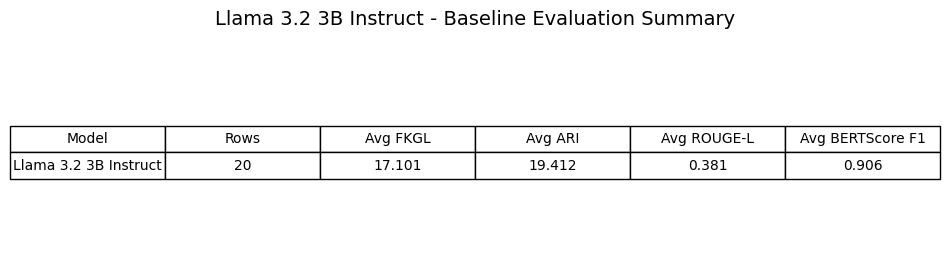

Saved summary table image to: /content/llama32_summary_table.png


In [19]:
# Create summary table image for screenshot/report
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

plt.title(f"{MODEL_LABEL} - Baseline Evaluation Summary", fontsize=14, pad=14)

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

IMAGE_PATH = "/content/llama32_summary_table.png"
plt.savefig(IMAGE_PATH, bbox_inches="tight", dpi=200)
plt.show()

print(f"Saved summary table image to: {IMAGE_PATH}")

In [20]:
# Optional: clear memory
for name in ["model", "tokenizer", "processor"]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared.")


Memory cleared.
